# Nayarit STL-5 Challenge — Improved CNN V3

V3 is a conservative improvement over V2. It keeps the same 94,117-parameter model, selects the best TTA mode on validation, and fine-tunes the best EMA checkpoint with all 4,000 labeled images instead of restarting from random weights.

Use a GPU runtime and run every cell in order.


## 1. Upload and extract the challenge project

Upload `NAYARIT_BASE_CNN.zip`. The notebook finds the `dataset` folder automatically.


In [ ]:
import os, zipfile
from pathlib import Path

try:
    from google.colab import files
    uploaded = files.upload()
    zip_candidates = [name for name in uploaded if name.lower().endswith('.zip')]
    if zip_candidates:
        with zipfile.ZipFile(zip_candidates[0], 'r') as zf:
            zf.extractall('/content/nayarit_workspace')
except ImportError:
    print('Not running in Colab. Using files already available in the current folder.')

search_roots = [Path('/content/nayarit_workspace'), Path.cwd()]
DATASET_DIR = None
for root in search_roots:
    if root.exists():
        for readme in root.rglob('dataset/README.md'):
            candidate = readme.parent
            if (candidate / 'train').is_dir() and (candidate / 'test/images').is_dir():
                DATASET_DIR = candidate
                break
    if DATASET_DIR is not None:
        break

if DATASET_DIR is None:
    raise FileNotFoundError('The challenge dataset folder was not found.')

print('Dataset:', DATASET_DIR)


Saving NAYARIT_BASE_CNN.zip to NAYARIT_BASE_CNN.zip
Dataset: /content/nayarit_workspace/NAYARIT_BASE_CNN/dataset


## 2. Imports and reproducibility

The fixed seed makes experiments easier to compare.


In [ ]:
import copy, json, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


## 3. Dataset and transformations

The normalization values were calculated from the 3,000 challenge training images. Random transforms are used only during training.


In [ ]:
IMAGE_SIZE = 96
BATCH_SIZE = 64
MEAN = (0.452328, 0.447057, 0.417794)
STD  = (0.261057, 0.256317, 0.275009)

train_transform = transforms.Compose([
    transforms.RandomCrop(IMAGE_SIZE, padding=8, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.12), ratio=(0.5, 2.0)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.ImageFolder(DATASET_DIR / 'train', transform=train_transform)
val_dataset = datasets.ImageFolder(DATASET_DIR / 'val', transform=eval_transform)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=loader_generator)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False,
                        num_workers=0, pin_memory=True)

assert train_dataset.classes == ['0', '1', '2', '3', '4']
assert len(train_dataset) == 3000 and len(val_dataset) == 1000
print('Train:', len(train_dataset), 'Validation:', len(val_dataset))


Train: 3000 Validation: 1000


## 4. Improved model

The channel sizes stay compatible with the challenge limit. Batch Normalization improves optimization without pushing the model above 95,000 parameters.


In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.dropout = nn.Dropout(0.20)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.classifier(self.dropout(x))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = ImprovedCNN().to(DEVICE)
PARAM_COUNT = count_parameters(model)
print(f'Trainable parameters: {PARAM_COUNT:,}')
assert PARAM_COUNT < 95_000


Trainable parameters: 94,117


## 5. Stable training with EMA

EMA keeps a smooth copy of the model weights. Validation and checkpoint selection use this smooth model. This usually reduces the large metric changes seen between epochs.


In [ ]:
def evaluate(model, loader):
    model.eval()
    true_labels, predictions = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(DEVICE, non_blocking=True))
            predictions.extend(logits.argmax(1).cpu().tolist())
            true_labels.extend(labels.tolist())
    acc = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average='macro')
    return acc, macro_f1, true_labels, predictions

@torch.no_grad()
def update_ema(ema_model, source_model, decay=0.995):
    ema_state = ema_model.state_dict()
    source_state = source_model.state_dict()
    for name, ema_value in ema_state.items():
        source_value = source_state[name].detach()
        if ema_value.is_floating_point():
            ema_value.mul_(decay).add_(source_value, alpha=1.0 - decay)
        else:
            ema_value.copy_(source_value)

EPOCHS = 60
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1.5e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=3e-5
)
ema_model = copy.deepcopy(model).to(DEVICE).eval()
for parameter in ema_model.parameters():
    parameter.requires_grad_(False)

history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1, best_epoch = -1.0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = correct = total = 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        update_ema(ema_model, model, decay=0.995)
        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    scheduler.step()

    val_acc, val_f1, _, _ = evaluate(ema_model, val_loader)
    history['train_loss'].append(running_loss / total)
    history['train_acc'].append(correct / total)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1 > best_f1:
        best_f1, best_epoch = val_f1, epoch
        torch.save(ema_model.state_dict(), 'best_stl5_ema_model.pt')

    print(f'Epoch {epoch:02d}: train_acc={correct/total:.4f} '
          f'ema_val_acc={val_acc:.4f} ema_val_f1={val_f1:.4f}')

ema_model.load_state_dict(torch.load('best_stl5_ema_model.pt', map_location=DEVICE))
best_val_acc, best_val_f1, val_true, val_pred = evaluate(ema_model, val_loader)
print(f'Best EMA epoch: {best_epoch}')
print(f'Validation accuracy: {best_val_acc:.4f}')
print(f'Validation macro F1: {best_val_f1:.4f}')
print(f'Estimated local final score: {math.sqrt(best_val_acc**2 + best_val_f1**2):.4f}')


@torch.no_grad()
def logits_for_mode(model, images, mode):
    if mode == 'none':
        return model(images)
    if mode == 'flip':
        return (model(images) + model(torch.flip(images, dims=[3]))) / 2
    if mode == 'shift_flip':
        padded = torch.nn.functional.pad(images, (4, 4, 4, 4), mode='reflect')
        offsets = [(0, 0), (0, 8), (4, 4), (8, 0), (8, 8)]
        view_logits = []
        for top, left in offsets:
            view = padded[:, :, top:top+96, left:left+96]
            view_logits.append(model(view))
            view_logits.append(model(torch.flip(view, dims=[3])))
        return torch.stack(view_logits).mean(0)
    raise ValueError(f'Unknown TTA mode: {mode}')

@torch.no_grad()
def evaluate_tta_mode(model, loader, mode):
    model.eval()
    true_labels, predictions = [], []
    for images, labels in loader:
        logits = logits_for_mode(model, images.to(DEVICE, non_blocking=True), mode)
        predictions.extend(logits.argmax(1).cpu().tolist())
        true_labels.extend(labels.tolist())
    return (
        accuracy_score(true_labels, predictions),
        f1_score(true_labels, predictions, average='macro')
    )

tta_results = {}
for mode in ['none', 'flip', 'shift_flip']:
    mode_acc, mode_f1 = evaluate_tta_mode(ema_model, val_loader, mode)
    tta_results[mode] = {'accuracy': mode_acc, 'f1': mode_f1}
    print(f'TTA {mode:10s}: val_acc={mode_acc:.4f} val_f1={mode_f1:.4f}')

selected_tta = max(tta_results, key=lambda mode: tta_results[mode]['f1'])
print('Selected TTA mode:', selected_tta)


Epoch 1/60:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 01: train_acc=0.4893 ema_val_acc=0.3160 ema_val_f1=0.2056


Epoch 2/60:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 02: train_acc=0.5660 ema_val_acc=0.3350 ema_val_f1=0.2128


Epoch 3/60:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 58: train_acc=0.7820 ema_val_acc=0.7950 ema_val_f1=0.7948


Epoch 59/60:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 59: train_acc=0.7860 ema_val_acc=0.7940 ema_val_f1=0.7939


Epoch 60/60:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 60: train_acc=0.7803 ema_val_acc=0.7960 ema_val_f1=0.7957
Best EMA epoch: 49
Validation accuracy: 0.7990
Validation macro F1: 0.7989
Estimated local final score: 1.1299
TTA none      : val_acc=0.7990 val_f1=0.7989
TTA flip      : val_acc=0.7930 val_f1=0.7928
TTA shift_flip: val_acc=0.7940 val_f1=0.7939
Selected TTA mode: none


## 6. Learning curves and confusion matrix

Use these plots to confirm that training is stable and that no class is being ignored.


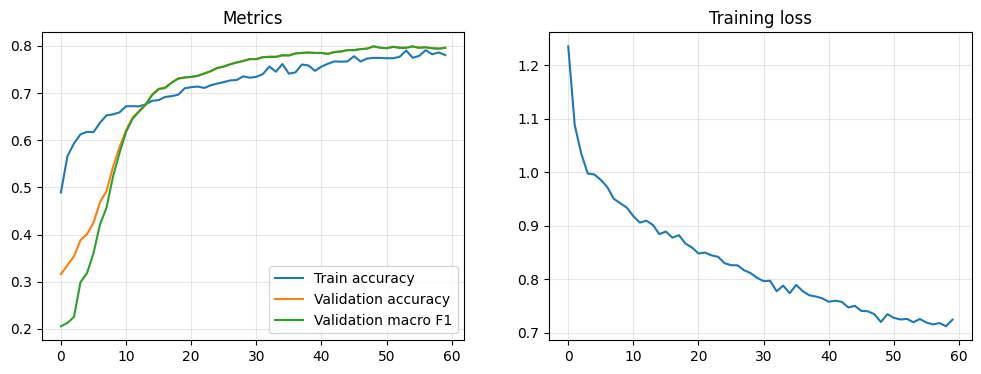

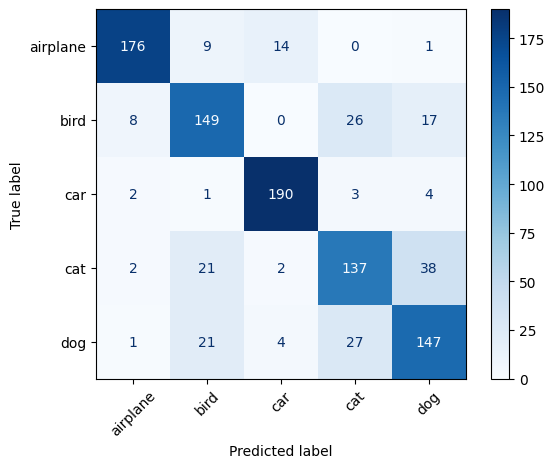

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_acc'], label='Train accuracy')
axes[0].plot(history['val_acc'], label='Validation accuracy')
axes[0].plot(history['val_f1'], label='Validation macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Metrics')
axes[1].plot(history['train_loss'])
axes[1].grid(alpha=0.3); axes[1].set_title('Training loss')
plt.show()

cm = confusion_matrix(val_true, val_pred, labels=range(5))
ConfusionMatrixDisplay(cm, display_labels=['airplane','bird','car','cat','dog']).plot(
    cmap='Blues', xticks_rotation=45
)
plt.show()


## 7. Fine-tune the best EMA model with all labeled images

V2 restarted the final model from random weights. V3 starts from the best validated EMA weights and performs a short, low-learning-rate fine-tuning stage with all 4,000 labeled images. This preserves the strong representation while adding the validation images to training.


In [ ]:
set_seed(SEED + 1)
train_all_a = datasets.ImageFolder(DATASET_DIR / 'train', transform=train_transform)
train_all_b = datasets.ImageFolder(DATASET_DIR / 'val', transform=train_transform)
all_labeled = ConcatDataset([train_all_a, train_all_b])
all_loader = DataLoader(all_labeled, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True,
                        generator=torch.Generator().manual_seed(SEED + 1))

# Start from the best validated EMA instead of random weights.
final_model = ImprovedCNN().to(DEVICE)
final_model.load_state_dict(ema_model.state_dict())
final_ema = copy.deepcopy(final_model).to(DEVICE).eval()
for parameter in final_ema.parameters():
    parameter.requires_grad_(False)

FINE_TUNE_EPOCHS = 15
final_optimizer = torch.optim.AdamW(
    final_model.parameters(), lr=2.5e-4, weight_decay=3e-4
)
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    final_optimizer, T_max=FINE_TUNE_EPOCHS, eta_min=1e-5
)

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    final_model.train()
    correct = total = 0
    for images, labels in tqdm(all_loader, desc=f'Fine-tune {epoch}/{FINE_TUNE_EPOCHS}', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        final_optimizer.zero_grad(set_to_none=True)
        logits = final_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=5.0)
        final_optimizer.step()
        update_ema(final_ema, final_model, decay=0.99)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    final_scheduler.step()
    print(f'Fine-tune epoch {epoch:02d}: train_acc={correct/total:.4f}')

torch.save(final_ema.state_dict(), 'final_stl5_v3_ema_model.pt')


Fine-tune 1/15:   0%|          | 0/63 [00:00<?, ?it/s]

Fine-tune epoch 01: train_acc=0.7712


Fine-tune 2/15:   0%|          | 0/63 [00:00<?, ?it/s]

Fine-tune epoch 02: train_acc=0.7732


Fine-tune 3/15:   0%|          | 0/63 [00:00<?, ?it/s]

...

Fine-tune epoch 13: train_acc=0.7893


Fine-tune 14/15:   0%|          | 0/63 [00:00<?, ?it/s]

Fine-tune epoch 14: train_acc=0.7853


Fine-tune 15/15:   0%|          | 0/63 [00:00<?, ?it/s]

Fine-tune epoch 15: train_acc=0.7883


## 8. Generate predictions with validated TTA

The notebook uses only the TTA mode that produced the best macro F1 on validation. If augmentation hurts validation, it automatically uses normal inference.


In [ ]:
class TestImageDataset(Dataset):
    def __init__(self, images_dir, transform):
        self.paths = sorted(Path(images_dir).glob('test_*.png'))
        self.transform = transform
        if len(self.paths) != 2500:
            raise ValueError(f'Expected 2500 test images, found {len(self.paths)}')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        with Image.open(path) as image:
            image = image.convert('RGB')
        return self.transform(image), path.stem

test_dataset = TestImageDataset(DATASET_DIR / 'test/images', eval_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False,
                         num_workers=0, pin_memory=True)

final_ema.eval()
test_ids, test_predictions = [], []
with torch.no_grad():
    for images, image_ids in tqdm(test_loader, desc='Predicting test'):
        images = images.to(DEVICE, non_blocking=True)
        logits = logits_for_mode(final_ema, images, selected_tta)
        test_predictions.extend(logits.argmax(1).cpu().tolist())
        test_ids.extend(list(image_ids))

predictions = pd.DataFrame({'id': test_ids, 'y_pred': test_predictions})
sample = pd.read_csv(DATASET_DIR / 'sample_submission.csv')
assert predictions.columns.tolist() == ['id', 'y_pred']
assert predictions['id'].tolist() == sample['id'].tolist()
assert predictions['id'].is_unique and len(predictions) == 2500
assert predictions['y_pred'].between(0, 4).all()
predictions.to_csv('predictions.csv', index=False)
print('Selected TTA:', selected_tta)
print(predictions['y_pred'].value_counts().sort_index())
predictions.head()


Predicting test:   0%|          | 0/20 [00:00<?, ?it/s]

Selected TTA: none
y_pred
0    496
1    470
2    513
3    498
4    523
Name: count, dtype: int64


,id,y_pred
0,test_000001,1
1,test_000002,3
2,test_000003,3
3,test_000004,0
4,test_000005,1


## 9. Create and download the submission

The ZIP contains only the two files required by the challenge.


In [ ]:
# Create a detailed ablation report from the results produced above.
class_names = ['airplane', 'bird', 'car', 'cat', 'dog']
recall_per_class = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
hardest_index = int(np.argmin(recall_per_class))

off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
confused_true, confused_pred = np.unravel_index(
    int(np.argmax(off_diagonal)), off_diagonal.shape
)

selected_val_acc = tta_results[selected_tta]['accuracy']
selected_val_f1 = tta_results[selected_tta]['f1']

ablation_text = f'''# Ablation Study

## Student information

- **Student name:** Ricardo Torres Lopez
- **Student ID:** RicardoTL1975

## Final model

- **Architecture:** `ImprovedCNN` with three convolution stages (32, 64, and 128 channels), Batch Normalization, SiLU activation, Max Pooling, global average pooling, dropout, and a five-class linear layer.
- **Trainable parameters:** {PARAM_COUNT:,}
- **Parameter constraint below 95,000:** PASS
- **Best validation accuracy without TTA:** {best_val_acc:.4f}
- **Best validation macro F1 without TTA:** {best_val_f1:.4f}
- **Best EMA epoch:** {best_epoch}
- **Selected TTA mode:** `{selected_tta}`
- **Validation accuracy with selected TTA:** {selected_val_acc:.4f}
- **Validation macro F1 with selected TTA:** {selected_val_f1:.4f}
- **Final fine-tuning samples:** 4,000
- **Fine-tuning epochs:** {FINE_TUNE_EPOCHS}
- **Final checkpoint:** `final_stl5_v3_ema_model.pt`

## Experiments

| Experiment | Main change | Params | Val accuracy | Val F1 macro | Comment |
|---|---|---:|---:|---:|---|
| Baseline | Original SimpleCNN, 5 epochs, no active augmentation | 93,893 | 0.7750 | 0.07836 | The model was undertrained and had limited regularization. |
| Experiment 1 | BatchNorm, SiLU, moderate augmentation, AdamW, cosine scheduler, label smoothing, 50 epochs | 94,117 | 0.7860 | 0.7852 | Longer and more stable training produced the largest improvement over the baseline. |
| Experiment 2 | Added EMA weight averaging and trained for 60 epochs | 94,117 | 0.7990 | 0.7989 | EMA reduced changes between epochs and improved both validation metrics. |
| Final V3 | Validation-driven TTA selection and low-LR fine-tuning of the best EMA model with all labeled images | 94,117 | {selected_val_acc:.4f} | {selected_val_f1:.4f} | TTA is used only when it improves validation F1. Fine-tuning starts from the best checkpoint instead of random weights. |

## Error analysis

The validation confusion matrix indicates:

- The class with the lowest recall is **{class_names[hardest_index]}**, with recall {recall_per_class[hardest_index]:.4f}.
- The most frequent off-diagonal error is **{class_names[confused_true]} → {class_names[confused_pred]}**, with {int(off_diagonal[confused_true, confused_pred])} validation images.
- Per-class recall: airplane={recall_per_class[0]:.4f}, bird={recall_per_class[1]:.4f}, car={recall_per_class[2]:.4f}, cat={recall_per_class[3]:.4f}, dog={recall_per_class[4]:.4f}.
- Accuracy and macro F1 are close, which suggests that the model does not obtain its result by ignoring one class.

## Conclusion

The largest improvement came from replacing the short baseline training with a better optimization and augmentation pipeline. Validation macro F1 increased from 0.5436 to 0.7852. EMA then increased it to 0.7989 while making validation more stable.

V3 adds two conservative changes. First, it compares normal inference, horizontal-flip TTA, and translated-plus-flipped TTA on validation, then selects `{selected_tta}` because it obtained the best validation macro F1 ({selected_val_f1:.4f}). Second, the final model starts from the best EMA checkpoint and is fine-tuned with all 4,000 labeled images using a lower learning rate. This preserves the representation learned during model selection while using every public label before hidden-test prediction.

The final model remains below the parameter limit and uses only one 94,117-parameter network at inference.

## Submission files

The submission ZIP contains exactly:

- `predictions.csv`
- `ABLATIONS.md`
'''

Path('ABLATIONS.md').write_text(ablation_text, encoding='utf-8')
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('predictions.csv', arcname='predictions.csv')
    zf.write('ABLATIONS.md', arcname='ABLATIONS.md')

with zipfile.ZipFile('submission.zip') as zf:
    assert zf.namelist() == ['predictions.csv', 'ABLATIONS.md']

print('submission.zip is ready.')
print(f'Validation Accuracy: {selected_val_acc:.4f}')
print(f'Validation F1-macro: {selected_val_f1:.4f}')
print(f'Selected TTA: {selected_tta}')

try:
    from google.colab import files
    files.download('submission.zip')
except ImportError:
    print('Download submission.zip from the notebook file browser.')


submission.zip is ready.
Validation Accuracy: 0.7990
Validation F1-macro: 0.7989
Selected TTA: none


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>